In [2]:
# !pip install pyts
# !pip install dtaidistance

# Домашнее задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом. 
Постарайтесь сделать их как можно более похожими, и в тоже время различными. 

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [3]:
import matplotlib.pyplot as plt
import numpy as np

Генерация сигнала

1 тип - гармонический (косинус)

2 тип - модифицированный синус

3 тип - пульс - сигнал

Для выполнения дз надо нагенерить 21 сигнал, по 7 сигналов каждого типа

In [4]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

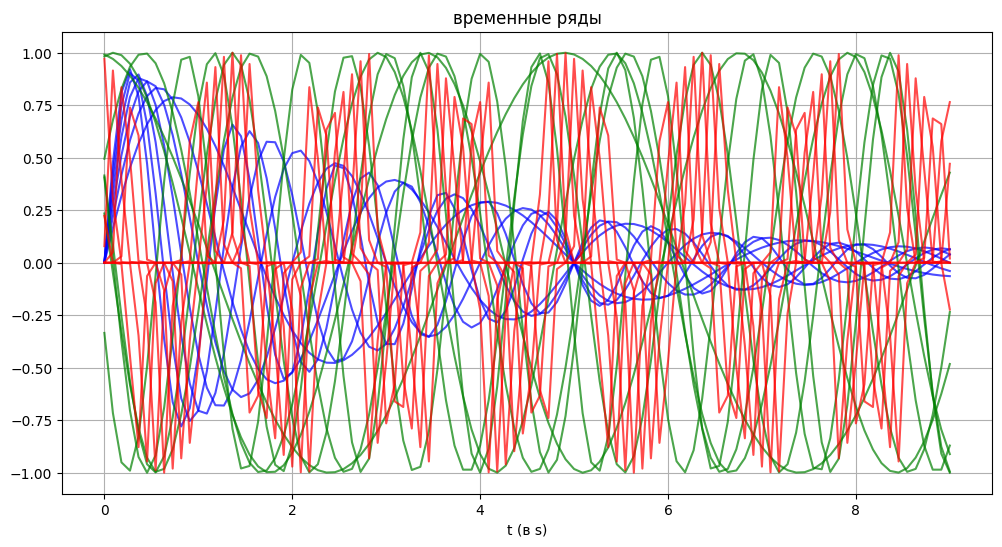

In [11]:
# индекс и отсчет времени в секундах
time_index = np.linspace(0, 9, 100)

tseries_list = {'Time': time_index}
np.random.seed(42)  # для воспроизводимости
d = np.random.random(size=10)

N = 7  # количество образцов в каждом типе сигналов

# гармонические колебания (косинус)
for i in range(N):
    freq = 0.2 + i * 0.1                     # частота от 0.2 до 0.8
    phase = np.random.random() * 2 * np.pi    # случайная фаза
    tseries_list["Tc"+str(i)] = np.cos(2 * np.pi * freq * time_index + phase)

# модифицированный синус (затухающий синус)
for i in range(N):
    freq = 0.3 + i * 0.1                     # частота от 0.3 до 0.9
    decay = 0.3                              # коэффициент затухания
    tseries_list["Ts"+str(i)] = np.sin(2 * np.pi * freq * time_index) * np.exp(-decay * time_index)

# пульс сигнал (острые пики, как у кардиосигнала)
for i in range(N):
    freq_pulse = 0.8                         # частота пульсаций
    # возведение в высокую степень даёт узкие положительные пики
    tseries_list["Tp"+str(i)] = np.sin(2 * np.pi * freq_pulse * (time_index + i * 0.1)) ** 15

# отрисовка всех сигналов
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(N):
    plt.plot(time_index, tseries_list["Ts"+str(i)], '-b', alpha=0.7)
for i in range(N):
    plt.plot(time_index, tseries_list["Tc"+str(i)], '-g', alpha=0.7)
for i in range(N):
    plt.plot(time_index, tseries_list["Tp"+str(i)], '-r', alpha=0.7)

plt.title(r'временные ряды')
plt.xlabel(r't (в s)')
plt.grid()
plt.show()

# Понимание Динамическое искажение (деформация) времени (Dynamic time warping, DTW)

DTW - это метод, который вычисляет оптимальное соответствие между двумя заданными последовательностями (например, временными рядами) с определенными ограничениями и правилами:

1. Каждый индекс из первой последовательности должен быть сопоставлен с одним или несколькими индексами из другой последовательности и наоборот

1. Первый индекс из первой последовательности должен совпадать с первым индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Последний индекс из первой последовательности должен совпадать с последним индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Отображение индексов из первой последовательности на индексы из другой последовательности должно монотонно возрастать, и наоборот, т. е. если j>i являются индексами из первой последовательности, то в другой последовательности не должно быть двух индексов l> k, так что индекс i совпадает с индексом l, а индекс j - с индексом k, и наоборот.

Рассмотрим два временных ряда $x$ и $x^{\prime}$ соответствующей длины n и m. Предполагается, что все элементы этих рядов лежат в одном и том же  p - одномерном пространство и точные временные метки, в которые происходят наблюдения, не принимаются во внимание, важен только их порядок.

Более формально задача оптимизации записывается в виде:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left( \sum_{(i, j) \in \pi} d(x_i, x^\prime_j)^q \right)^{\frac{1}{q}}
$

 
Здесь путь выравнивания $\pi$  длины K  представляет собой последовательность K  пары индексов $((i_0,j_0),..,(i_{K-1},j_{K-1}))$
 и  $A(x,x^{\prime})$
 представляет собой набор всех допустимых путей. Чтобы считаться допустимым, путь должен удовлетворять следующим условиям:

Начало (соответственно, конец) временных рядов сопоставляются друг с другом:

$
\pi_0 = (0, 0)
$

$
\pi_{K-1} = (n - 1, m - 1)
$

Последовательность монотонно увеличивается в обоих $i$ и $j$  и все индексы временных рядов должны отображаться хотя бы один раз, что может быть записано как:

$
i_{k-1} \leq i_k \leq i_{k-1} + 1
$

$
j_{k-1} \leq j_k \leq j_{k-1} + 1
$


Другим способом представления  DTW является использование двоичной матрицы, ненулевые элементы которой соответствуют совпадениям между элементами временного ряда. Это представление связано с представлением последовательности индексов, использованным выше:

$
\begin{equation}
(A_\pi)_{i,j} = \left\{ \begin{array}{rl} 1 & \text{ if } (i, j) \in \pi \\
                                      0 & \text{ otherwise}
                        \end{array} \right. \,\,\,\,\,\,\, .
\end{equation}
$

Тогда  DTW может быть выражено через скалярные произведения следующим образом:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left\langle A_\pi,  D_q({x}, {x}^\prime) \right\rangle^{\frac{1}{q}}
 $ 

Решение поставленной задачи оптимизации может быть найдено с помощью динамического программирования.
Обозначим:

$
R_{i,j} = DTW_q({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})^q
$

где ${x}_{\rightarrow i}$ - обозначает наблюдение ряда до отметки i

Тогда получаем реккурентную формулу:

$
\begin{aligned}
R_{i,j} 
    &= \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
        \sum_{(k, l) \in \pi} d(x_k, x^\prime_l)^q \\
    &\stackrel{*}{=} d(x_i, x^\prime_j)^q +
        \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
            \sum_{(k, l) \in \pi[:-1]} d(x_k, x^\prime_l)^q \\
    &\stackrel{**}{=} d(x_i, x^\prime_j)^q +
        \min ({\color{Blue}R_{i-1, j}}, {\color{Red}R_{i, j-1}}, {\color{ForestGreen}R_{i-1, j-1}})
\end{aligned}
$

\* - потому, что последний элемент на допустимом пути должен соответствовать последним элементам ряда.

** - результат условий смежности допустимых путей.

In [12]:
def distance_matrix(x, y, q) -> np.array:
    """
    Функция расчета матрицы расстояний между точками двух рядов 
    """
    mdist = np.zeros((len(y), len(x)))
    # Вложенные циклы для заполнения матрицы расстояниями |x[j] - y[i]|**q
    for i in range(len(y)):
        for j in range(len(x)):
            mdist[i, j] = abs(x[j] - y[i]) ** q
    return mdist

In [13]:
def DTW(x, x_s, q=1, isDTW=True):
    '''
        x: первый ряд
        x_s : второй ряд
        q : степень для вычисления базового расстояния
    '''
    N = len(x)
    M = len(x_s)
    
    # Матрица расстояний между точками (размер M x N)
    dist = distance_matrix(x, x_s, q)
    
    # Матрица накопленных стоимостей (размер (N+1) x (M+1))
    R = np.full((N+1, M+1), np.inf)
    R[0][0] = 0
    
    # Заполнение первой строки и первого столбца (граничные условия)
    for i in range(1, N+1):
        R[i][0] = R[i-1][0] + dist[0][i-1]   # сопоставляем все точки x с первой точкой x_s
    for j in range(1, M+1):
        R[0][j] = R[0][j-1] + dist[j-1][0]   # сопоставляем все точки x_s с первой точкой x
    
    # Рекуррентное заполнение матрицы
    for i in range(1, N+1):
        for j in range(1, M+1):
            # Рекуррентная формула: 
            # R[i][j] = dist[j-1][i-1] + min(R[i-1][j], R[i][j-1], R[i-1][j-1])
            R[i][j] = dist[j-1][i-1] + min(R[i-1][j], R[i][j-1], R[i-1][j-1])
    
    # Итоговое расстояние DTW
    dtw_distance = R[N][M]
    
    # Восстановление оптимального пути (для визуализации)
    pth = []
    i, j = N, M
    while i > 0 or j > 0:
        pth.append((i-1, j-1))
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            # Направление с минимальной стоимостью
            if R[i-1][j] <= R[i][j-1] and R[i-1][j] <= R[i-1][j-1]:
                i -= 1
            elif R[i][j-1] <= R[i-1][j-1]:
                j -= 1
            else:
                i -= 1
                j -= 1
    pth.reverse()
    
    return dtw_distance, pth, R

In [14]:
# Посчитаем DTW для двух временных рядов

# для простоты выделяем ряды, которые будем сравнивать
x = np.abs(tseries_list.get("Ts1", np.zeros(100)))
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))
x_p = np.abs(tseries_list.get("Tp2", np.zeros(100)))

s1 = DTW(x, x_s, q=2)
s2 = DTW(x, x_p, q=2)

print(f"DTW\nTs1 и Ts3 = {s1[0]}     Ts1 и Tp1 = {s2[0]}")

s11 = DTW(x, x_s, q=2, isDTW=False)
s21 = DTW(x, x_p, q=2, isDTW=False)

print(f"Dec\nTs1 и Ts3 = {s11[0]}     Ts1 и Tp1 = {s21[0]}")

DTW
Ts1 и Ts3 = 0.941215956212531     Ts1 и Tp1 = 9.485650167906384
Dec
Ts1 и Ts3 = 0.941215956212531     Ts1 и Tp1 = 9.485650167906384


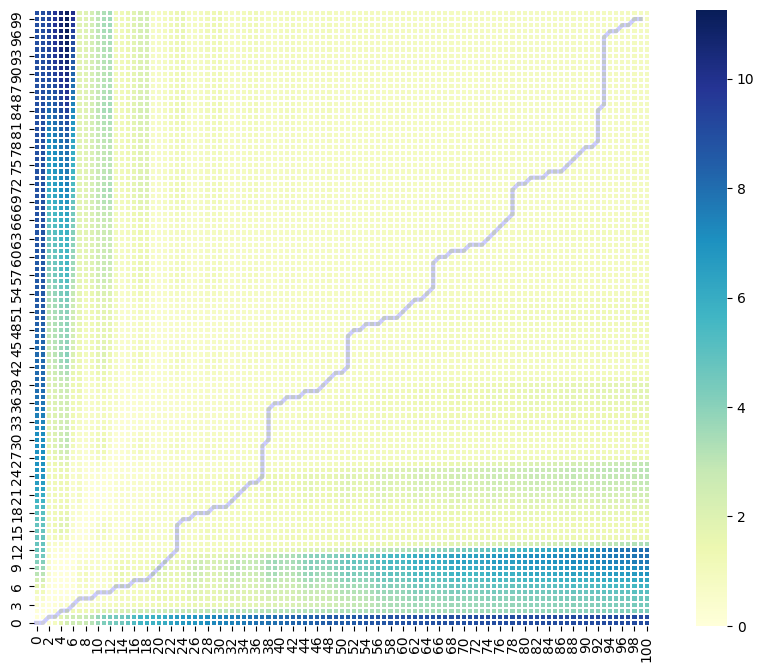

In [15]:
import seaborn as sbn
# Отрисуем матрицы весов расстояний Ts1 и Ts3 

cost_matrix = s1[2]
warp_path = s1[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

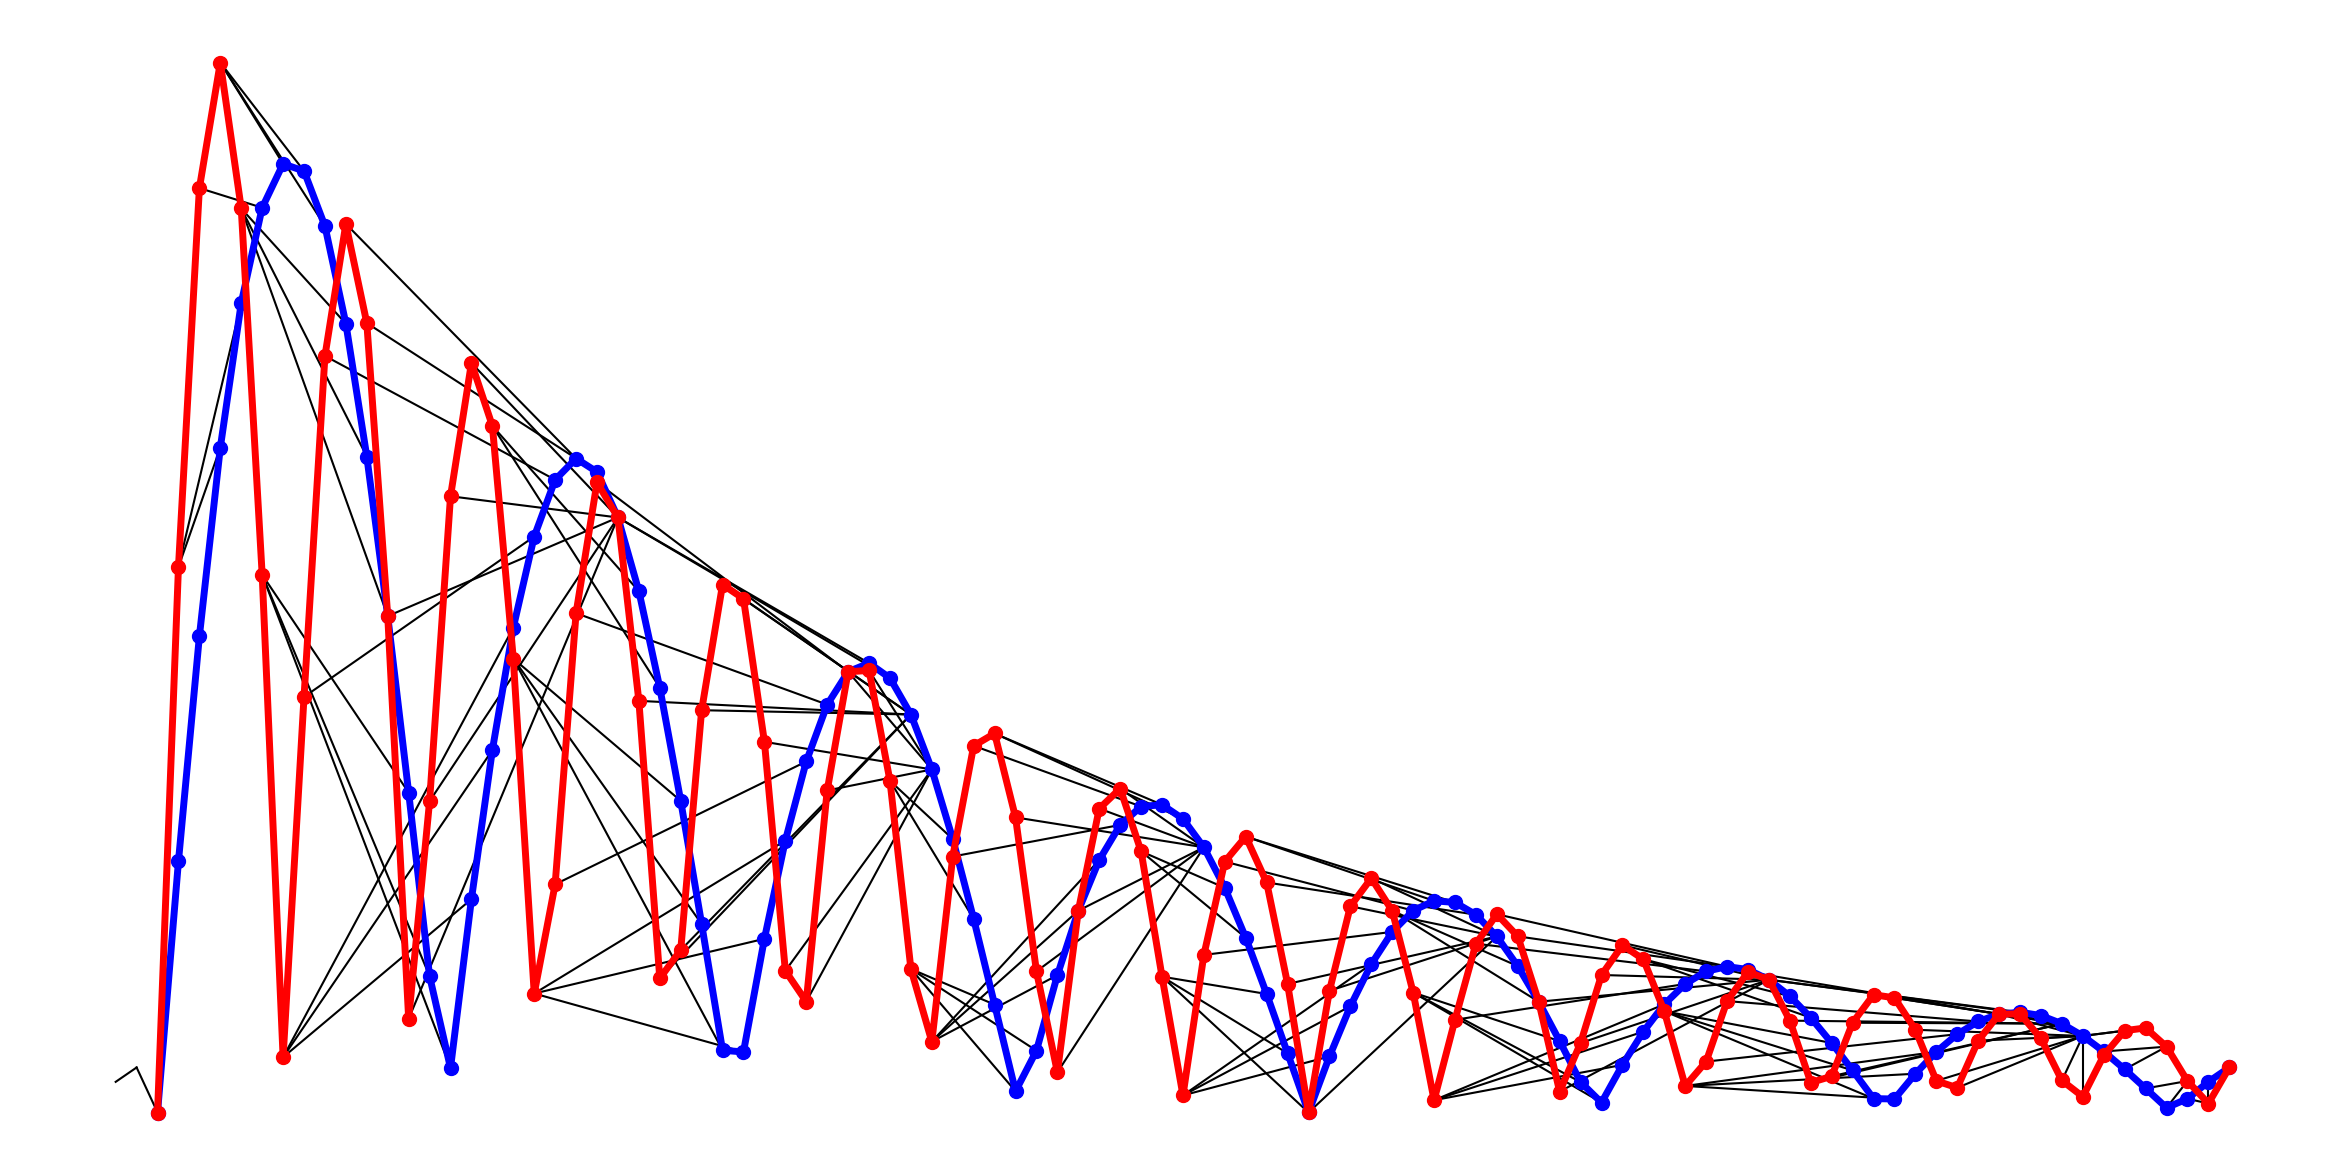

In [16]:
fig, ax = plt.subplots(figsize=(30, 15))


warp_path = s1[1]
x1 = x
x2 = x_s

# Remove the border and axes ticks
fig.patch.set_visible(True)
ax.axis('off')

for [map_x, map_y] in warp_path:   
    ax.set_facecolor('white')
    ax.plot([map_x-1, map_y-1], [x1[map_x-1], x2[map_y-1]], '-k')

ax.plot(x1, color='blue', marker='o', markersize=10, linewidth=5)
ax.plot(x2, color='red', marker='o', markersize=10, linewidth=5)
ax.tick_params(axis="both", which="major", labelsize=18)

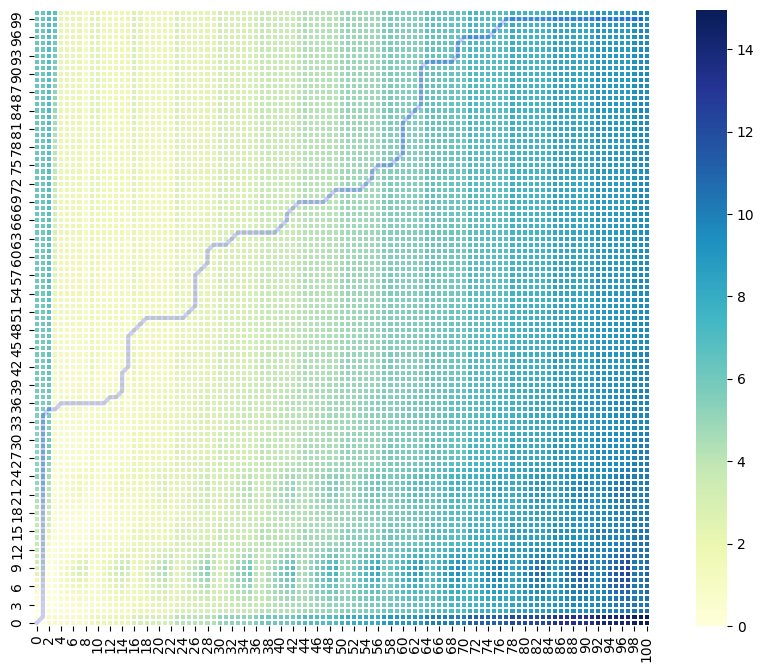

In [17]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1

cost_matrix = s2[2]
warp_path = s2[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

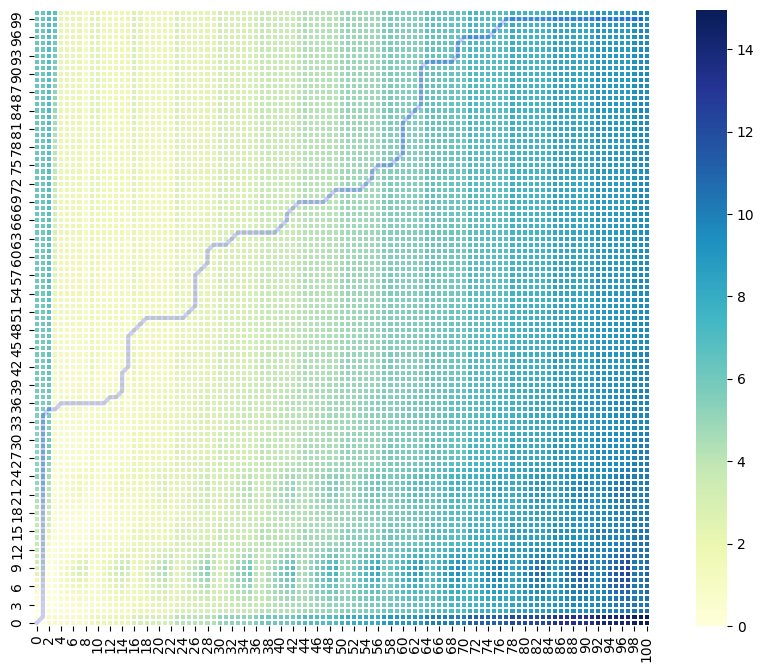

In [18]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1 без DTW

cost_matrix = s21[2]
warp_path = s21[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

А теперь попробуем вычислить тоже самое, но с помощью встроенных функций Python

In [19]:
from dtaidistance import dtw

x = np.abs(tseries_list.get("Ts1", np.zeros(100)))
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))

# Преобразуем в список или массив чисел (если строки – уже преобразовано ранее)
# Убедимся, что это числа
if isinstance(x, str):
    import re
    x = np.array(list(map(float, re.findall(r"[-+]?\d*\.?\d+", x))))
if isinstance(x_s, str):
    import re
    x_s = np.array(list(map(float, re.findall(r"[-+]?\d*\.?\d+", x_s))))

# Вычисляем DTW расстояние и пути
distance, paths = dtw.warping_paths(x, x_s)

print(f"DTW расстояние: {distance}")
print(f"Пути (информация о выравнивании): {paths}")

DTW расстояние: 0.9701628503568517
Пути (информация о выравнивании): [[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.         0.47850325 ... 3.01607417 3.01608445 3.01634312]
 [       inf 0.22040306 0.25810019 ... 2.06122825 2.07215614 2.08003752]
 ...
 [       inf 2.99843024 3.03446323 ... 0.9704724  0.97008079 0.97045845]
 [       inf 2.99855076 3.03225056 ... 0.97047269 0.97026707 0.97016285]
 [       inf 2.99881095 3.03051619 ... 0.9701089  0.9706244  0.97016285]]


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

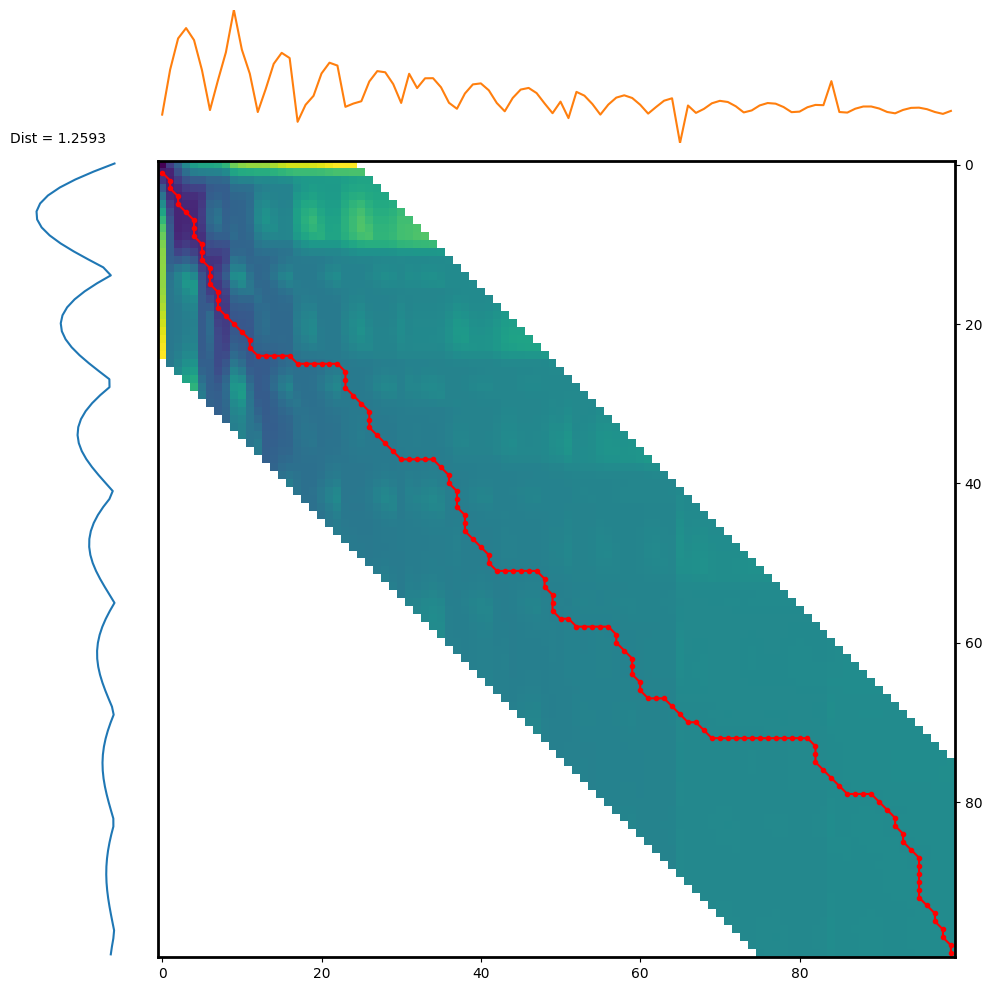

In [21]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np
xw = np.arange(0, 20, .5)
s1 = x
s2 = x_s
random.seed(1)
for idx in range(len(s2)):
    if random.random() < 0.05:
        s2[idx] += (random.random() - 0.5) / 2
d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(s1, s2, paths, path=best_path)

In [22]:
x = np.abs(tseries_list["Ts1"])
x_p = np.abs(tseries_list["Tp2"])


distance, paths = dtw.warping_paths(x, x_p)
print(distance)
print(paths)

3.0798782716052893
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.07900731 0.91869664 ... 3.81005068 3.866833   3.86688488]
 [       inf 0.16197195 0.69936704 ... 3.21748405 3.24740765 3.25358347]
 ...
 [       inf 2.4878554  2.64588386 ... 3.04790646 3.11605689 3.07980909]
 [       inf 2.48840135 2.64172186 ... 3.04466706 3.10984428 3.07981672]
 [       inf 2.48871491 2.63802019 ... 3.04195839 3.10464503 3.07987827]]


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

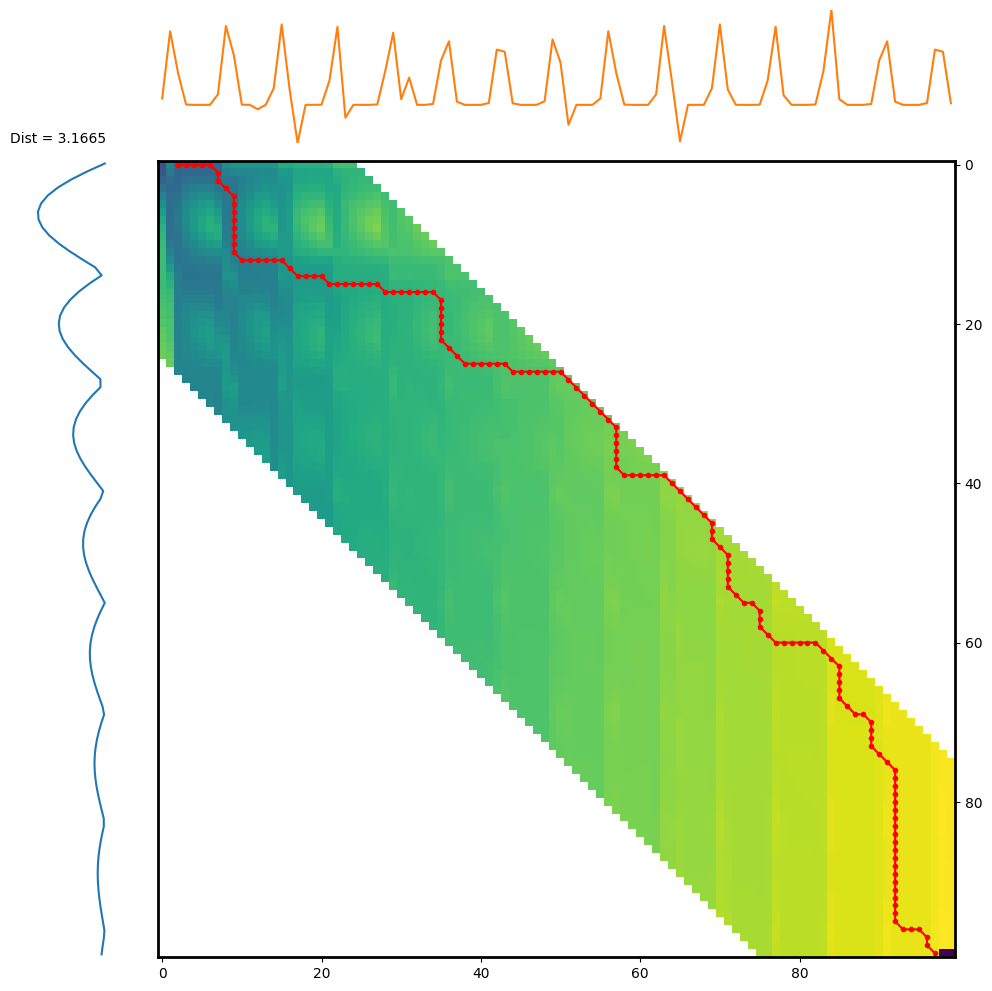

In [24]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np
xw = np.arange(0, 20, .5)
s1 = x
s2 = x_p
random.seed(1)
for idx in range(len(s2)):
    if random.random() < 0.05:
        s2[idx] += (random.random() - 0.5) / 2
d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(s1, s2, paths, path=best_path)

In [25]:
# переделываем датасет так, чтобы с ним можно было бы работать

x = []  # значения
Y = []  # целевая переменная

for v in tseries_list:
    if v != 'Time':
        x.append(tseries_list[v])
        c = v[:-1]
        if c == "Ts":
            Y.append(0)
        elif c == "Tc":
            Y.append(1)
        else:
            Y.append(2)

arr = np.arange(len(Y))
np.random.shuffle(arr)

print(Y)

X_train = []
X_test = []
y_train = []
y_test = []

train_indices = arr[:-5]   # все, кроме последних 5
test_indices = arr[-5:]    # последние 5

for idx in train_indices:
    X_train.append(x[idx])
    y_train.append(Y[idx])

for idx in test_indices:
    X_test.append(x[idx])
    y_test.append(Y[idx])

[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2]


In [26]:
from pyts.classification import KNeighborsClassifier

clf = KNeighborsClassifier(metric='dtw')
clf.fit(X_train, y_train)

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba([X_test[2]])}")
print(f"Истинный класс для предсказаний {y_test[2]}")

C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Accuracy 1.0
Вектор вероятности принадлежности к классам [[1. 0. 0.]]
Истинный класс для предсказаний 0


C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

In [32]:
import numpy as np
from pyts.classification import TimeSeriesForest
import matplotlib.pyplot as plt

clf = TimeSeriesForest(random_state=43)
clf.fit(X_train, y_train)

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba([X_test[2]])}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[0.866 0.01  0.124]]
Истинный класс для предсказаний 0


In [33]:
clf_eucl = KNeighborsClassifier(metric='euclidean')
clf_eucl.fit(X_train, y_train)

print(f"Accuracy {clf_eucl.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf_eucl.predict_proba([X_test[2]])}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 0.4
Вектор вероятности принадлежности к классам [[1. 0. 0.]]
Истинный класс для предсказаний 0
